# Telco Customer Churn Prediction: Exploratory Data Analysis (EDA)

## Project Objective
This notebook focuses on the exploratory data analysis phase of a telecom churn prediction project. The objective is to understand customer churn behavior, identify patterns linked to customer loss, and surface business insights that can support retention strategies before model training.

## Dataset Overview
The dataset contains customer demographics, subscription details, billing information, and service usage features.

**Target Variable:** `Churn` — indicates whether a customer left the telecom service.

## Project Context
Customer churn is a critical business problem in the telecom industry because retaining existing customers is usually more cost-effective than acquiring new ones. This analysis is designed to identify which customer segments are most likely to churn and which service or billing patterns may contribute to that outcome.

**Dataset Note:**  
This is a sample telecom churn dataset where each row represents one customer and whether they churned in the previous month.

## Environment Setup
Import the core Python libraries used for data manipulation, visualization, and exploratory analysis.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt

## Data Loading
Load the telecom churn dataset and inspect a few sample records to validate the schema, feature names, and target structure before deeper analysis.

In [2]:
df = pd.read_csv('Customer-Churn.csv')

## Initial Data Preview
Review the first few rows to confirm the dataset loaded correctly.

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Structure Review
Inspect the dataset shape, column names, data types, and summary statistics to understand the structure of the data before cleaning and analysis.

In [4]:
df.shape

(7043, 21)

In [5]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

In [6]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Initial Data Observations
- **SeniorCitizen** appears numeric, but it is actually a categorical indicator and should be interpreted as such.
- **Tenure:** 75% of customers have a tenure of less than 55 months, suggesting a meaningful portion of the customer base is relatively recent.
- **Monthly Charges:** This feature appears likely to be an important driver of churn and will be explored in more detail later.
- **TotalCharges** may require additional cleaning because it is often stored as an object/string in this dataset.

## Target Variable Review
Before analyzing features, it is helpful to understand the class balance of the target variable.

In [8]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [9]:
df['Churn'].value_counts()/len(df)*100

,count
Churn,
No,73.463013
Yes,26.536987


<Axes: xlabel='Churn'>

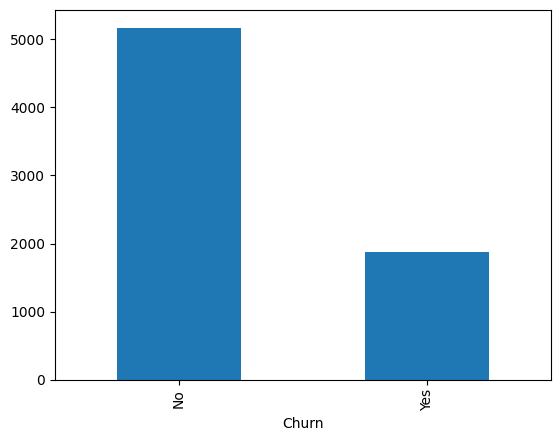

In [10]:
df['Churn'].value_counts().plot(kind='bar')

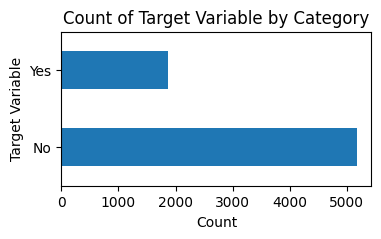

In [11]:
df['Churn'].value_counts().plot(kind='barh', figsize=(4, 2))
plt.xlabel("Count")
plt.ylabel("Target Variable")
plt.title("Count of Target Variable by Category");

### Target Balance Summary
- The target variable is **imbalanced**, with an approximate ratio of **73:27** (non-churn vs churn).
- This is an important modeling consideration because class imbalance can affect evaluation metrics and model behavior.
- During EDA, it is useful to analyze how other features differ across churned vs retained customers.

## Missing Values and Dataset Health Check
Perform a quick structural review using `info()` and verify whether any fields contain missing values before cleaning.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [13]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


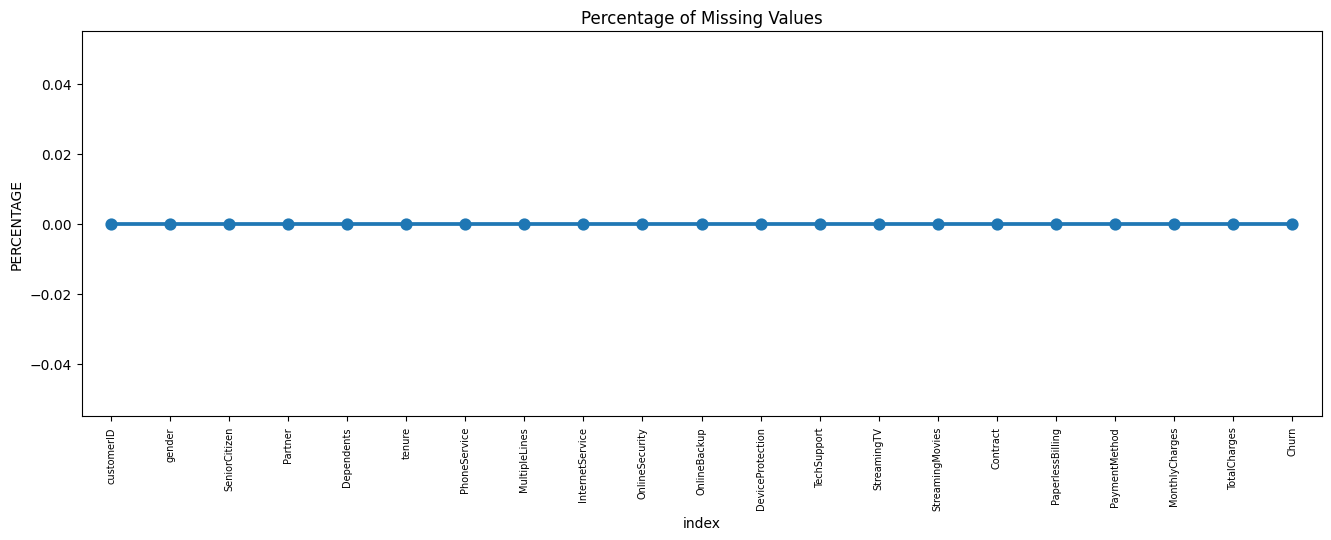

In [14]:
missing = pd.DataFrame((df.isnull().sum()) * 100 / df.shape[0]).reset_index()
plt.figure(figsize=(16, 5))
ax = sns.pointplot(x='index', y=0, data=missing)
plt.xticks(rotation=90, fontsize=7)
plt.title("Percentage of Missing Values")
plt.ylabel("PERCENTAGE")
plt.show()

### Missing Data - Initial Assessment

At first glance, the dataset appears to have no missing values. However, this telecom dataset often stores some blank values in `TotalCharges` as empty strings, which do not always appear as `NaN` until the column is converted to numeric.

**General guidance for missing values:**
- For features with low missingness, imputation may be appropriate depending on business context.
- For features with high missingness, dropping the column can sometimes be justified if the feature adds little value.
- Missingness should always be interpreted carefully — sometimes null values are meaningful.

## Data Cleaning

**1.** Create a working copy of the original dataset for cleaning and feature preparation.

In [15]:
new_df = df.copy()

**2.** Convert `TotalCharges` into a numeric feature.

In this dataset, `TotalCharges` can contain blank strings, so invalid values are coerced into `NaN`.

In [16]:
new_df.TotalCharges = pd.to_numeric(new_df.TotalCharges, errors='coerce')

In [17]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [18]:
new_df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


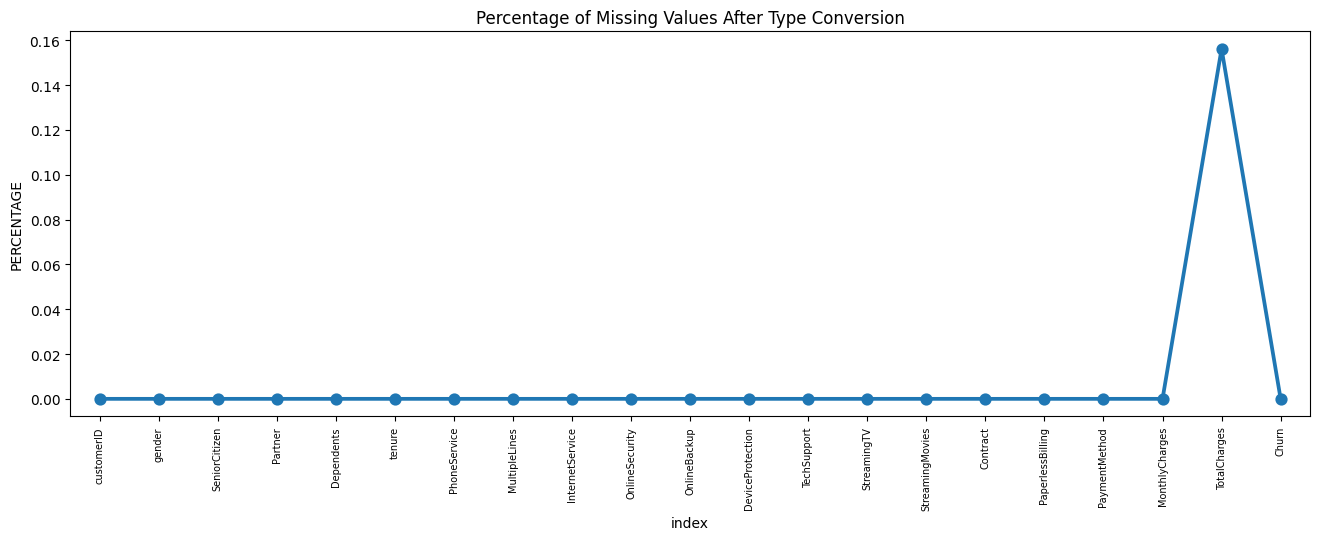

In [19]:
missing = pd.DataFrame((new_df.isnull().sum()) * 100 / new_df.shape[0]).reset_index()
plt.figure(figsize=(16, 5))
ax = sns.pointplot(x='index', y=0, data=missing)
plt.xticks(rotation=90, fontsize=7)
plt.title("Percentage of Missing Values After Type Conversion")
plt.ylabel("PERCENTAGE")
plt.show()

**3.** After conversion, `TotalCharges` now shows missing values. Review those records to understand the issue.

In [20]:
new_df.loc[new_df['TotalCharges'].isnull() == True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


**4.** Missing value treatment

Since these records represent a very small portion of the dataset (roughly **0.15%**), dropping them is a practical and low-risk cleaning choice for this EDA workflow.

In [21]:
new_df.dropna(how='any', inplace=True)

In [22]:
new_df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
new_df.shape

(7032, 21)

**5.** Create tenure bands to make retention patterns easier to interpret.

Grouping customers into 12-month tenure buckets makes it easier to analyze churn across customer lifecycle stages.

In [24]:
print(new_df['tenure'].max())

72


In [25]:
labels = ["{0} - {1}".format(i, i + 11) for i in range(1, 72, 12)]

print(labels)

['1 - 12', '13 - 24', '25 - 36', '37 - 48', '49 - 60', '61 - 72']


In [26]:
labels = ["{0} - {1}".format(i, i + 11) for i in range(1, 72, 12)]

new_df['tenure_group'] = pd.cut(new_df.tenure, range(1, 80, 12), right=False, labels=labels)

In [27]:
new_df['tenure_group'].value_counts()

,count
tenure_group,
1 - 12,2175
61 - 72,1407
13 - 24,1024
25 - 36,832
49 - 60,832
37 - 48,762


**6.** Remove columns that are no longer required for analysis-ready modeling features.

In [28]:
new_df.drop(columns=['customerID', 'tenure'], axis=1, inplace=True)

In [29]:
new_df.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1 - 12


### Data Cleaning Summary
At this point:
- `TotalCharges` has been converted to numeric.
- Invalid blank entries in `TotalCharges` were removed.
- A more interpretable feature, `tenure_group`, was created.
- Non-modeling identifier columns were removed.

This leaves the dataset in a cleaner state for feature exploration.

## Exploratory Data Analysis
This section explores how individual features and selected feature combinations relate to customer churn.

### Univariate Analysis
Review the distribution of individual predictors and compare them against the churn outcome to identify early patterns.

In [30]:
new_df.head(5)

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1 - 12


In [31]:
new_df.Churn.value_counts() / len(new_df) * 100

,count
Churn,
No,73.421502
Yes,26.578498


<Axes: xlabel='SeniorCitizen', ylabel='count'>

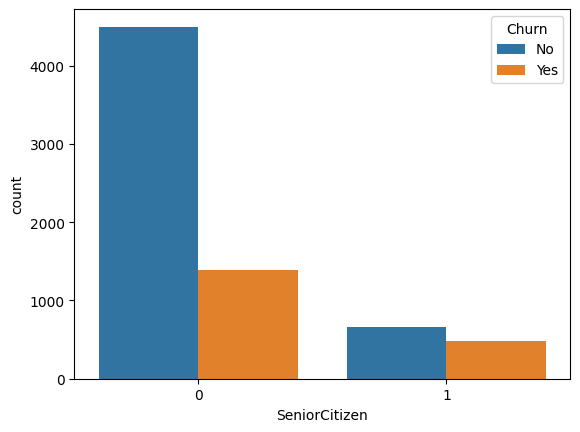

In [32]:
sns.countplot(data=new_df, x='SeniorCitizen', hue='Churn')

<Axes: xlabel='gender', ylabel='count'>

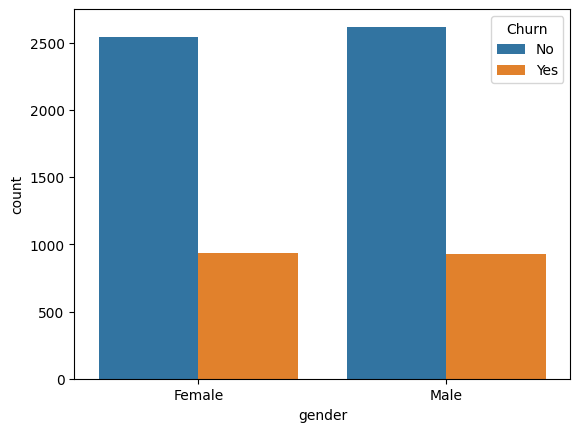

In [33]:
sns.countplot(data=new_df, x='gender', hue='Churn')

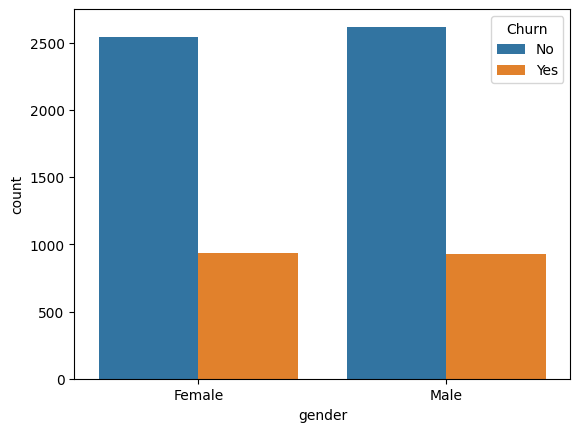

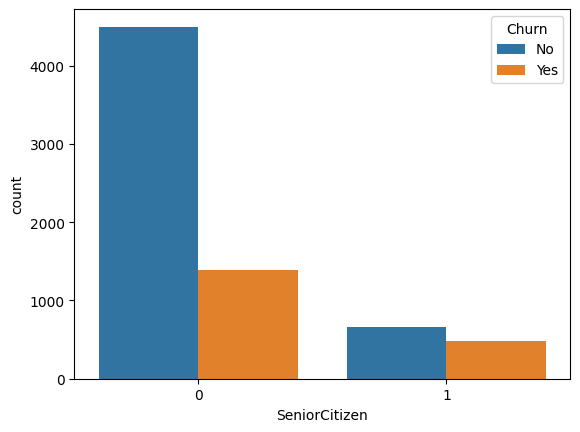

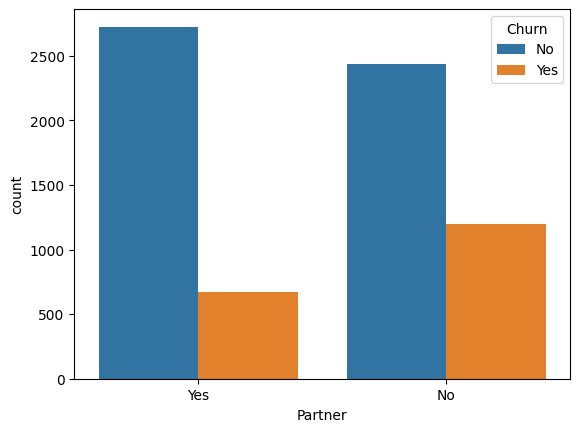

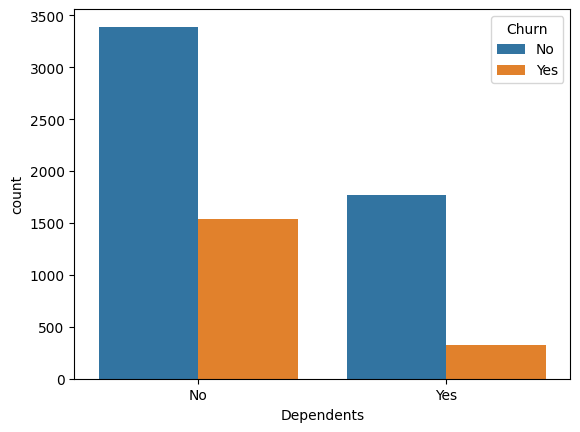

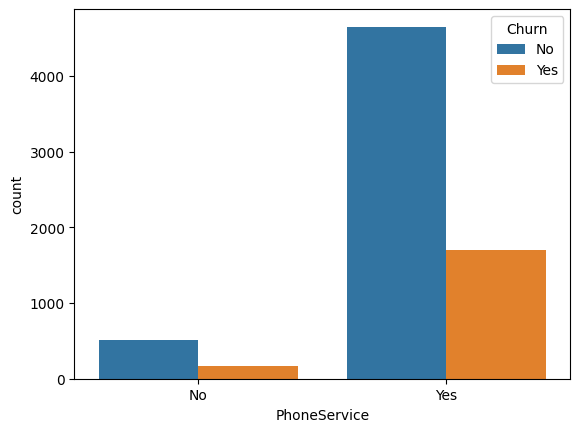

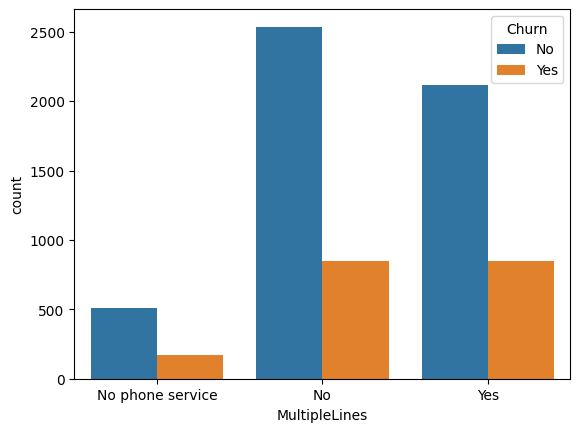

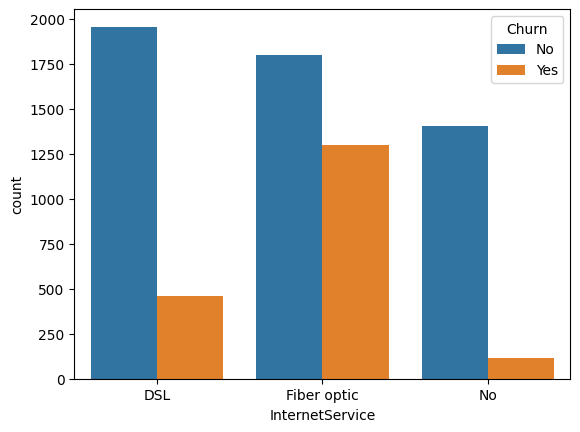

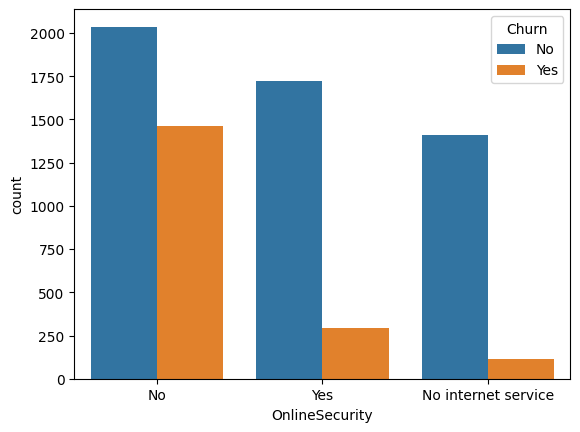

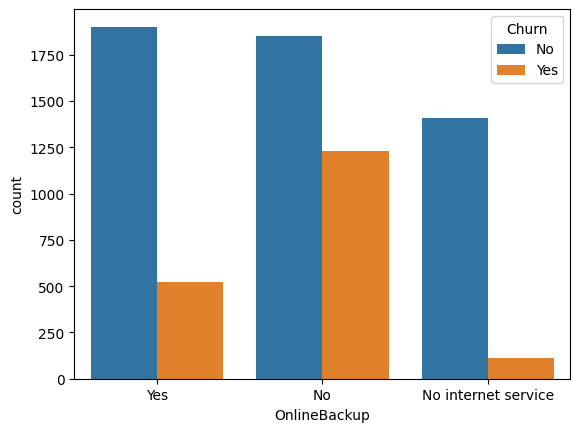

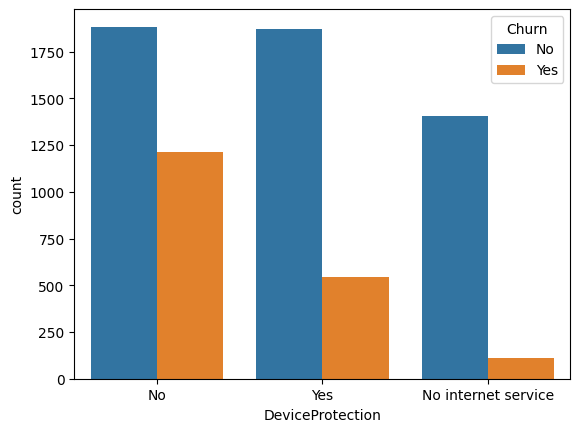

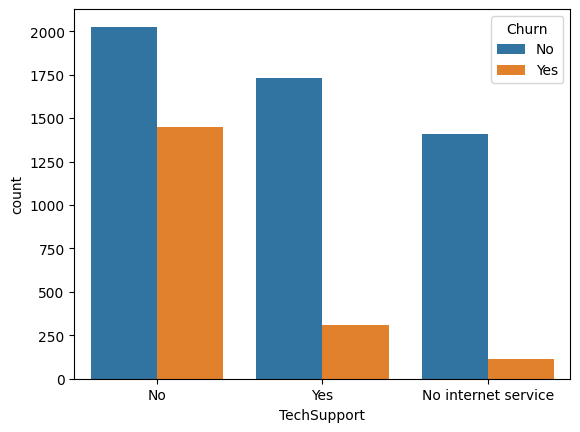

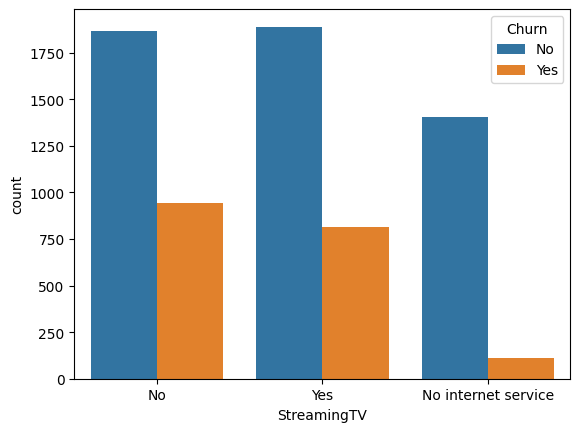

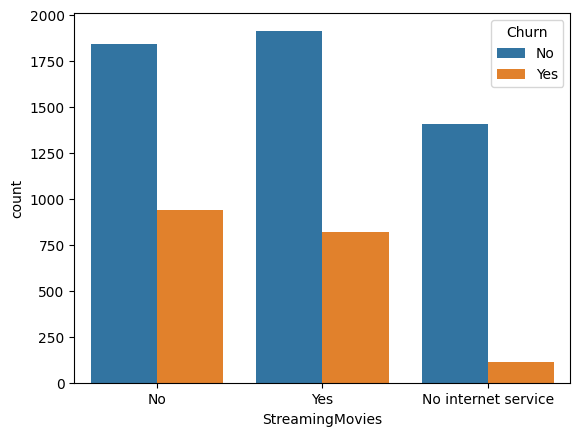

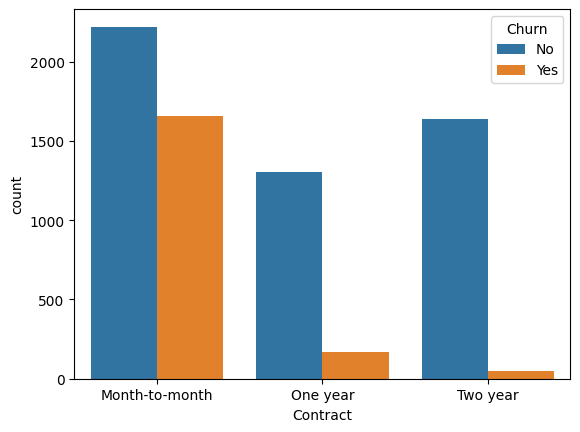

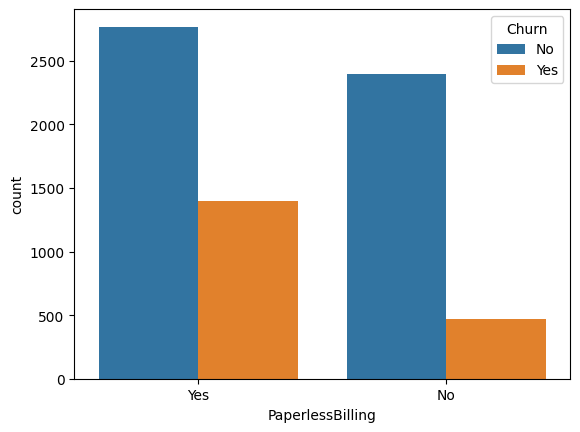

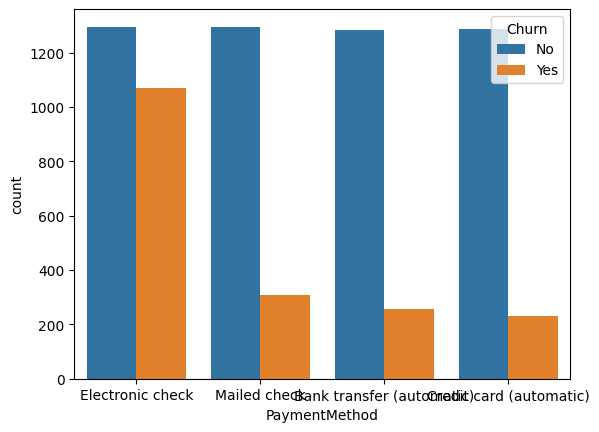

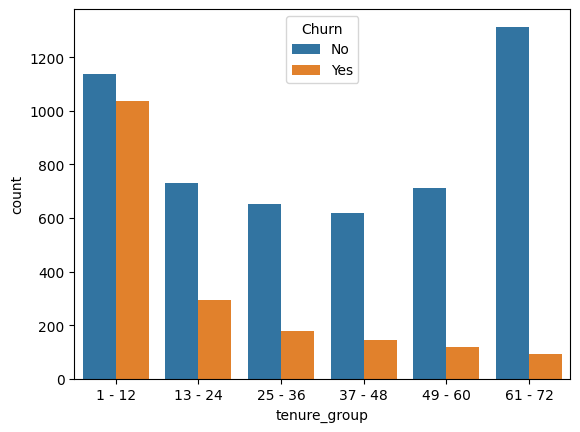

In [34]:
for i, predictor in enumerate(new_df.drop(columns=['Churn', 'TotalCharges', 'MonthlyCharges'])):
    plt.figure(i)
    sns.countplot(data=new_df, x=predictor, hue='Churn')

In [35]:
new_df.SeniorCitizen.value_counts()

,count
SeniorCitizen,
0,5890
1,1142


In [36]:
new_df1_target0 = new_df[new_df["Churn"] == 'No']
new_df1_target1 = new_df[new_df["Churn"] == 'Yes']

In [37]:
new_df1_target1.SeniorCitizen.value_counts()

,count
SeniorCitizen,
0,1393
1,476


In [38]:
new_df.gender.value_counts()

,count
gender,
Male,3549
Female,3483


In [39]:
new_df1_target1.gender.value_counts()

,count
gender,
Female,939
Male,930


In [40]:
pd.crosstab(new_df.PaymentMethod, new_df.Churn)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


**2.** Convert the target variable `Churn` into a binary numeric feature for correlation analysis and later modeling.

### Early Univariate Findings
Based on the initial charts:
- Certain service combinations and contract types show visibly different churn distributions.
- Features such as contract type, payment method, and support/security services appear especially important.
- Numeric feature relationships will be explored next to validate whether billing behavior and customer lifetime value correlate with churn.

In [41]:
new_df['Churn'] = np.where(new_df.Churn == 'Yes', 1, 0)

In [42]:
new_df.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,...,Electronic check,29.85,29.85,0,1 - 12
1,Male,0,No,No,Yes,...,Mailed check,56.95,1889.50,0,25 - 36
2,Male,0,No,No,Yes,...,Mailed check,53.85,108.15,1,1 - 12
3,Male,0,No,No,No,...,Bank transfer (automatic),42.30,1840.75,0,37 - 48
4,Female,0,No,No,Yes,...,Electronic check,70.70,151.65,1,1 - 12


**3.** Convert categorical variables into dummy variables to support correlation analysis and downstream modeling.

In [43]:
new_df_dummies = pd.get_dummies(new_df)
new_df_dummies.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1 - 12,tenure_group_13 - 24,tenure_group_25 - 36,tenure_group_37 - 48,tenure_group_49 - 60,tenure_group_61 - 72
0,0,29.85,29.85,0,True,False,False,True,True,False,...,False,False,True,False,True,False,False,False,False,False
1,0,56.95,1889.50,0,False,True,True,False,True,False,...,False,False,False,True,False,False,True,False,False,False
2,0,53.85,108.15,1,False,True,True,False,True,False,...,False,False,False,True,True,False,False,False,False,False
3,0,42.30,1840.75,0,False,True,True,False,True,False,...,True,False,False,False,False,False,False,True,False,False
4,0,70.70,151.65,1,True,False,True,False,True,False,...,False,False,True,False,True,False,False,False,False,False


### Feature Engineering Note
Dummy encoding is useful here because it enables direct correlation analysis with the binary target and prepares the dataset for downstream modeling.

### Monthly Charges vs Total Charges
Review the relationship between recurring monthly billing and accumulated lifetime charges.

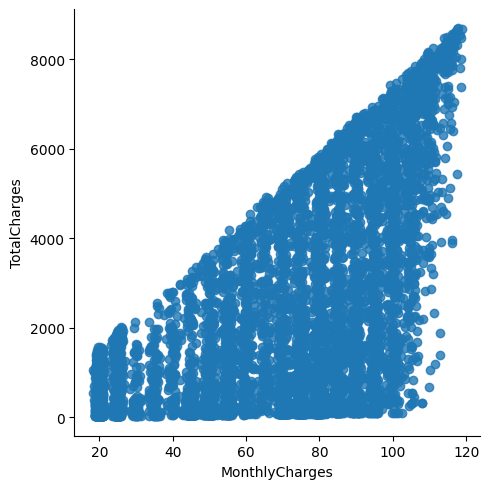

In [44]:
sns.lmplot(data=new_df_dummies, x='MonthlyCharges', y='TotalCharges', fit_reg=False)

In [45]:
new_df_dummies['MonthlyCharges'].corr(new_df_dummies['TotalCharges'])

np.float64(0.6510648032262027)

**Observation:** Total Charges increase as Monthly Charges increase, which is expected. However, this relationship is also influenced by tenure, since longer-tenure customers accumulate more total charges over time.

### Churn by Monthly Charges and Total Charges
Compare the distributions of billing-related features for churned vs retained customers.

/tmp/ipykernel_6726/1273935562.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Mth = sns.kdeplot(
/tmp/ipykernel_6726/1273935562.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Mth = sns.kdeplot(


Text(0.5, 1.0, 'Monthly Charges by Churn')

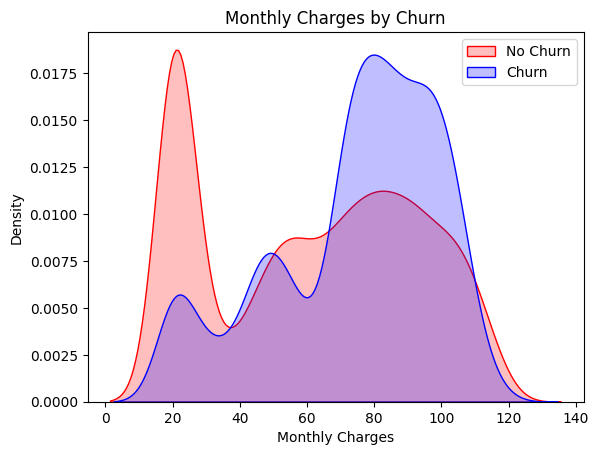

In [46]:
Mth = sns.kdeplot(
    new_df_dummies.MonthlyCharges[(new_df_dummies["Churn"] == 0)],
    color="Red",
    shade=True
)
Mth = sns.kdeplot(
    new_df_dummies.MonthlyCharges[(new_df_dummies["Churn"] == 1)],
    ax=Mth,
    color="Blue",
    shade=True
)
Mth.legend(["No Churn", "Churn"], loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('Monthly Charges')
Mth.set_title('Monthly Charges by Churn')

**Insight:** Churn appears higher among customers with relatively higher monthly charges.

/tmp/ipykernel_6726/2865957197.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(
/tmp/ipykernel_6726/2865957197.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(


Text(0.5, 1.0, 'Total Charges by Churn')

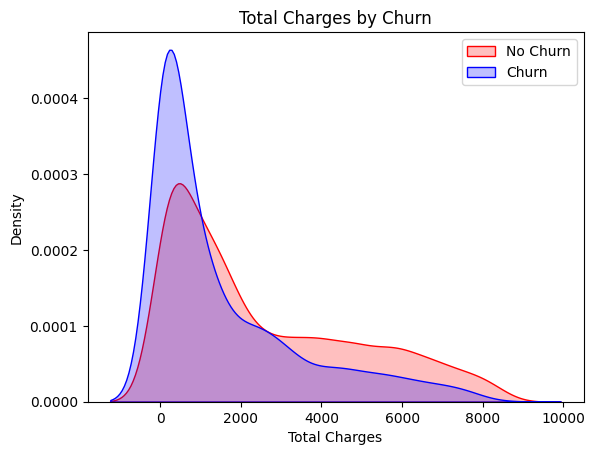

In [47]:
Tot = sns.kdeplot(
    new_df_dummies.TotalCharges[(new_df_dummies["Churn"] == 0)],
    color="Red",
    shade=True
)
Tot = sns.kdeplot(
    new_df_dummies.TotalCharges[(new_df_dummies["Churn"] == 1)],
    ax=Tot,
    color="Blue",
    shade=True
)
Tot.legend(["No Churn", "Churn"], loc='upper right')
Tot.set_ylabel('Density')
Tot.set_xlabel('Total Charges')
Tot.set_title('Total Charges by Churn')

**Interpretation:** Churn appears higher at lower total charges.

This becomes more intuitive when viewed alongside tenure and monthly charges:
- Customers with **lower tenure** have had less time to accumulate total charges.
- Customers with **higher monthly charges** may still show **low total charges** if they churn early.

Together, these patterns suggest that **higher monthly charges**, **lower tenure**, and **lower total charges** are linked to elevated churn risk.

### Correlation of Predictors with Churn
Build a simple correlation view to identify which encoded features are most positively or negatively associated with churn.

<Axes: >

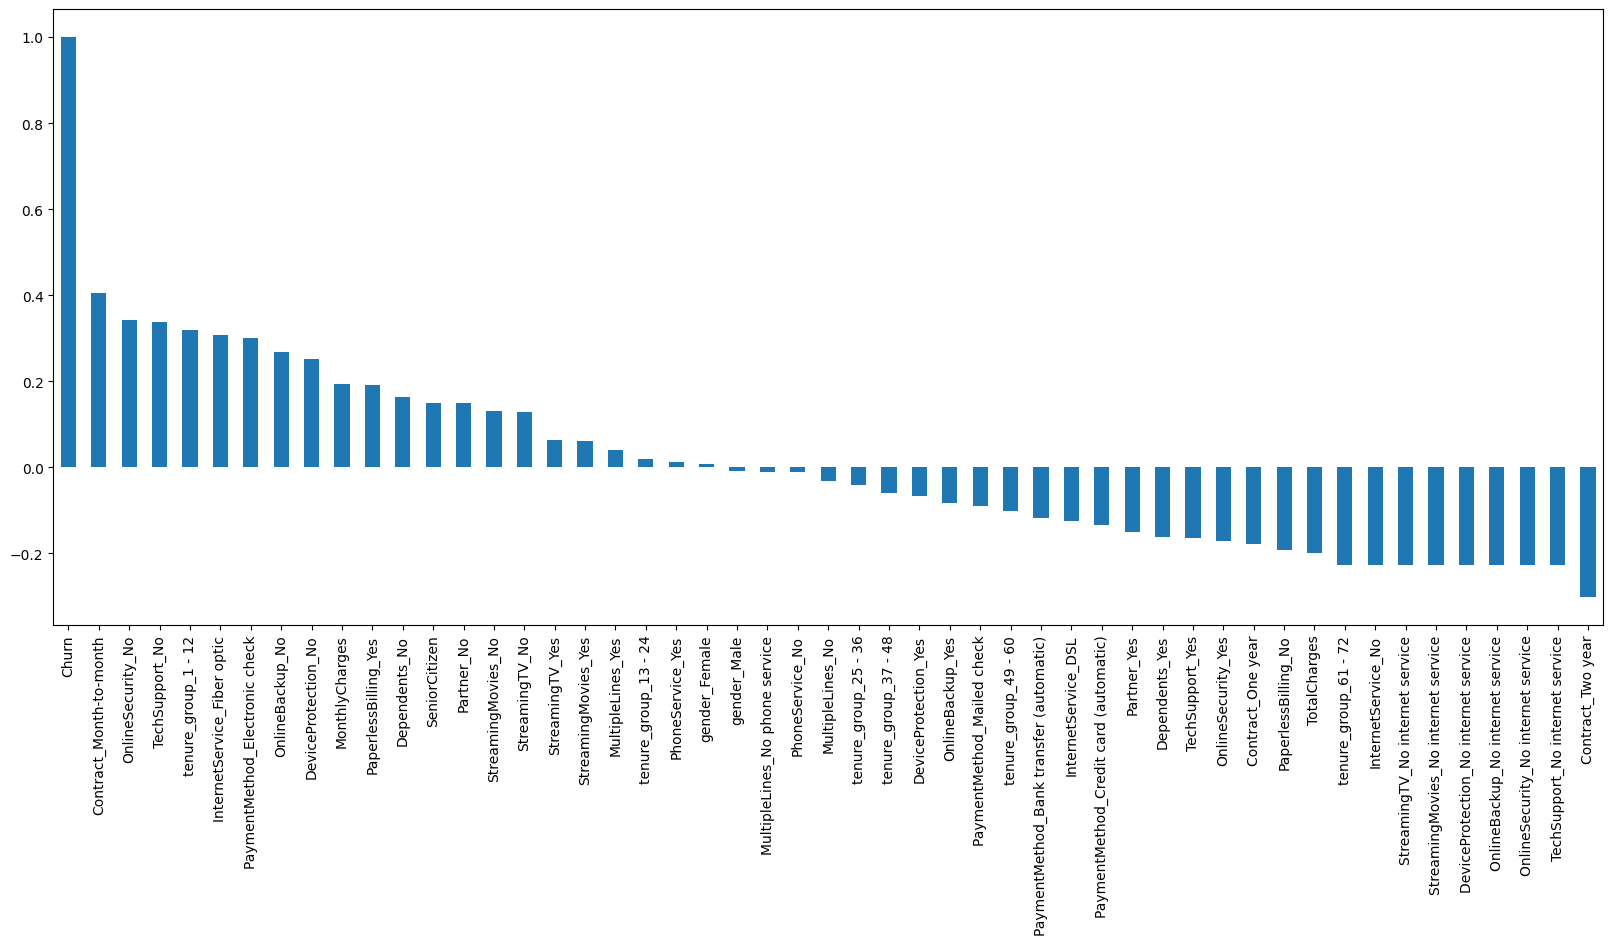

In [48]:
plt.figure(figsize=(20, 8))
new_df_dummies.corr()['Churn'].sort_values(ascending=False).plot(kind='bar')

### Correlation-Based Insight Summary

**Higher churn** is commonly associated with:
- **Month-to-month contracts**
- **No online security**
- **No tech support**
- **Lower tenure / first-year customers**
- **Fiber optic internet service**

**Lower churn** is commonly associated with:
- **Longer-term contracts**
- **Customers without internet-dependent add-ons**
- **Customers with longer tenure (especially multi-year customers)**

Some features such as **gender**, **phone service availability**, and **multiple lines** appear to have relatively limited standalone impact.

<Axes: >

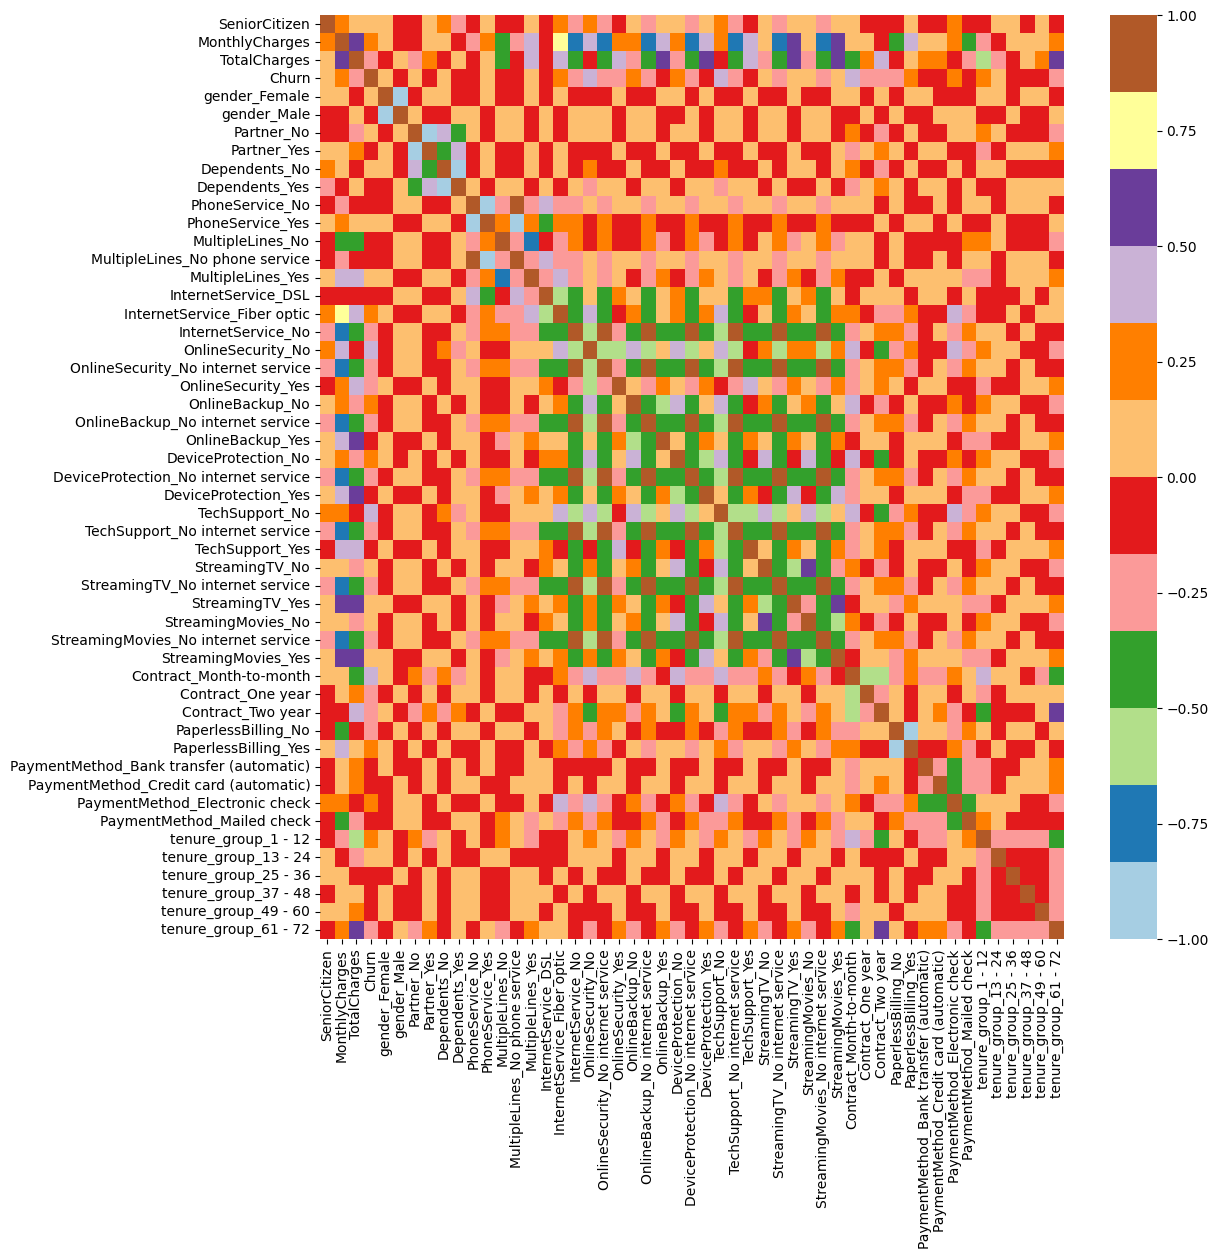

In [49]:
plt.figure(figsize=(12, 12))
sns.heatmap(new_df_dummies.corr(), cmap="Paired")

### Bivariate Analysis
Use focused visual comparisons across selected features to better understand which customer segments show stronger churn tendencies.

In [50]:
new_df1_target0 = new_df.loc[new_df["Churn"] == 0]
new_df1_target1 = new_df.loc[new_df["Churn"] == 1]

In [51]:
len(new_df1_target0)

5163

In [52]:
len(new_df1_target1)

1869

In [53]:
def uniplot(df, col, title, hue=None):

    sns.set_style('whitegrid')
    sns.set_context('talk')
    plt.rcParams["axes.labelsize"] = 20
    plt.rcParams['axes.titlesize'] = 22
    plt.rcParams['axes.titlepad'] = 30

    temp = pd.Series(data=hue)
    fig, ax = plt.subplots()
    width = len(df[col].unique()) + 7 + 4 * len(temp.unique())
    fig.set_size_inches(width, 8)
    plt.xticks(rotation=45)
    plt.yscale('log')
    plt.title(title)
    ax = sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index,
        hue=hue,
        palette='bright'
    )

    plt.show()

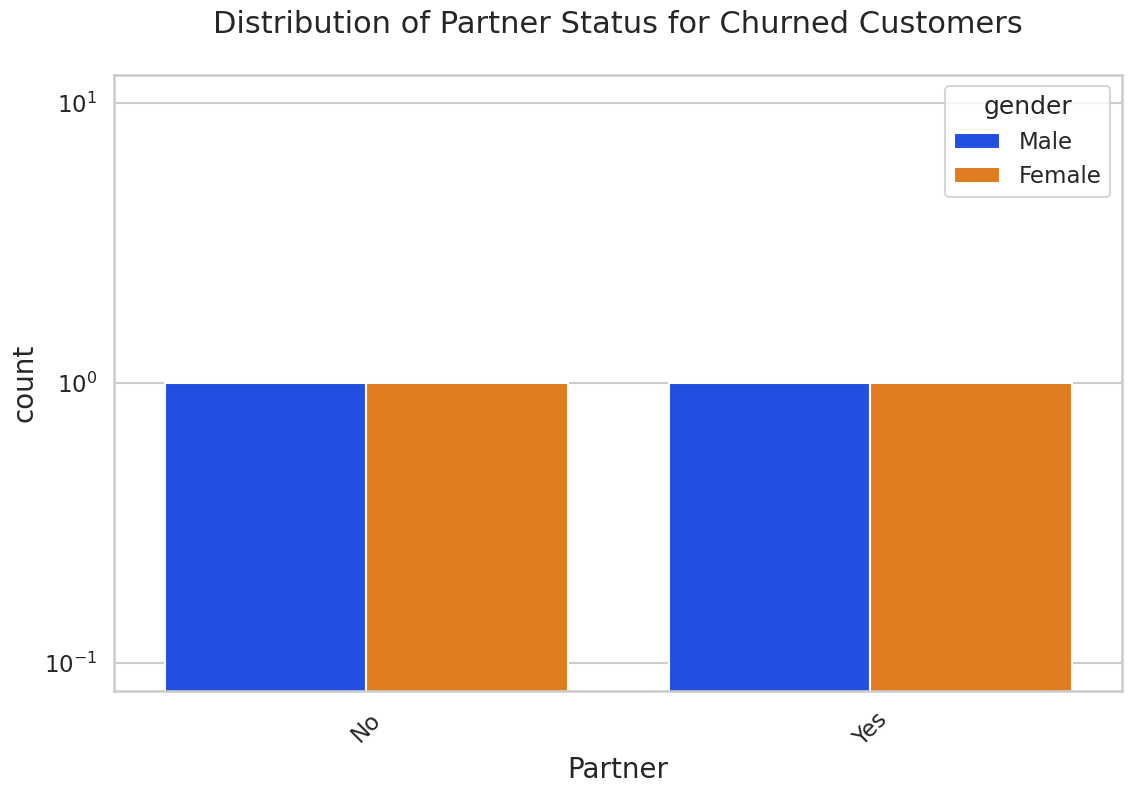

In [54]:
uniplot(new_df1_target1, col='Partner', title='Distribution of Partner Status for Churned Customers', hue='gender')

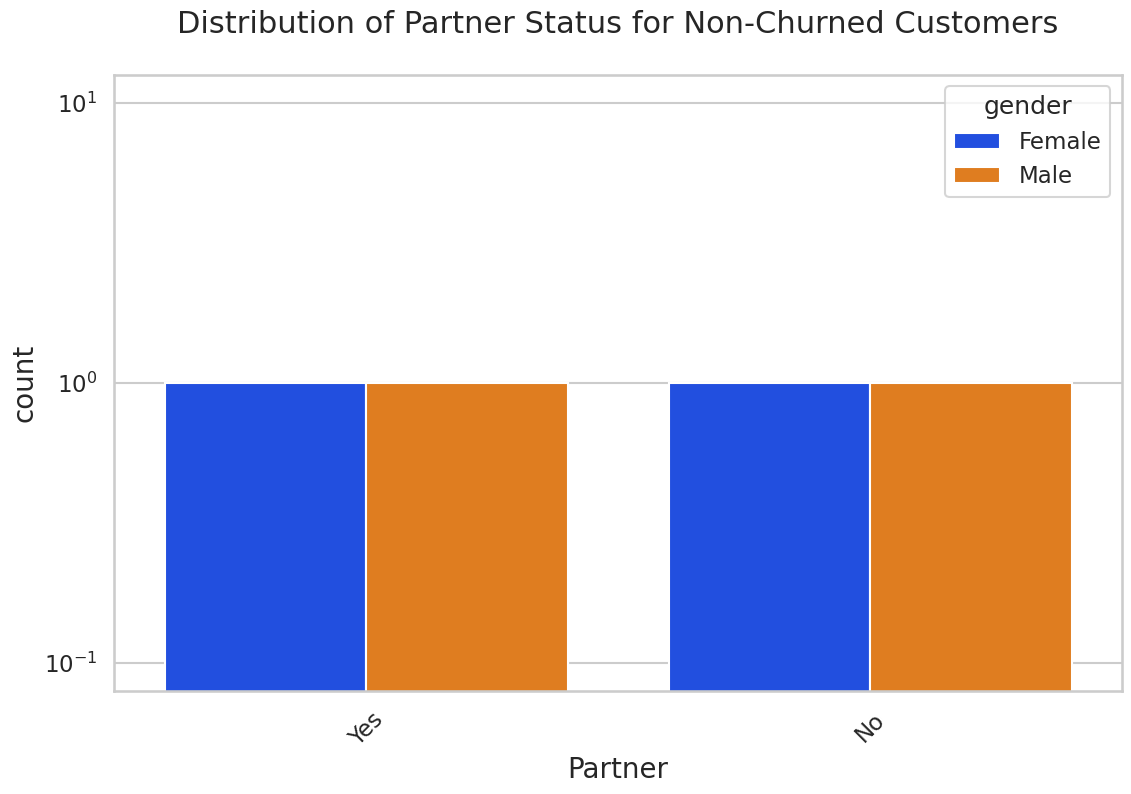

In [55]:
uniplot(new_df1_target0, col='Partner', title='Distribution of Partner Status for Non-Churned Customers', hue='gender')

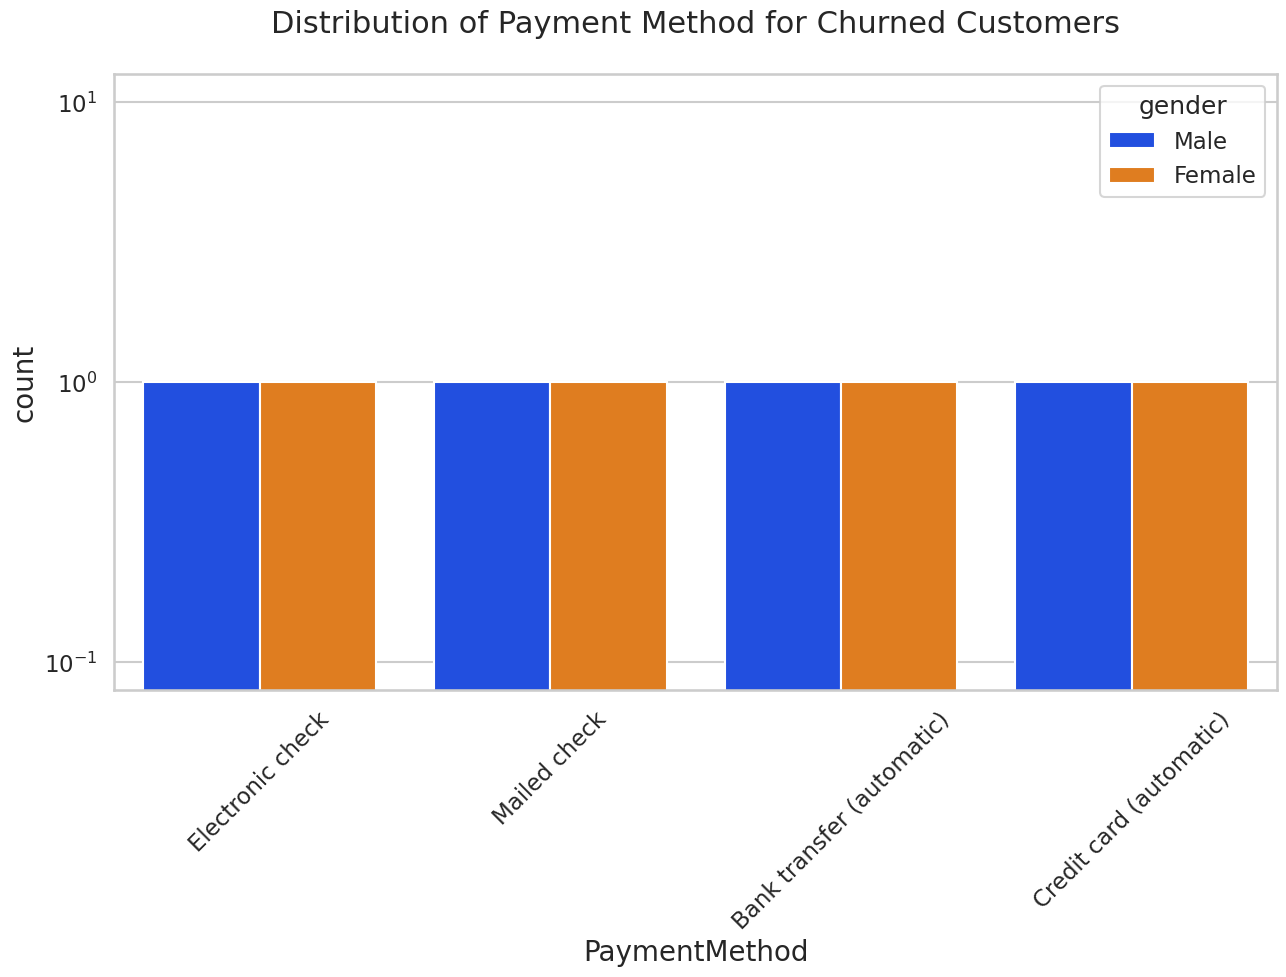

In [56]:
uniplot(new_df1_target1, col='PaymentMethod', title='Distribution of Payment Method for Churned Customers', hue='gender')

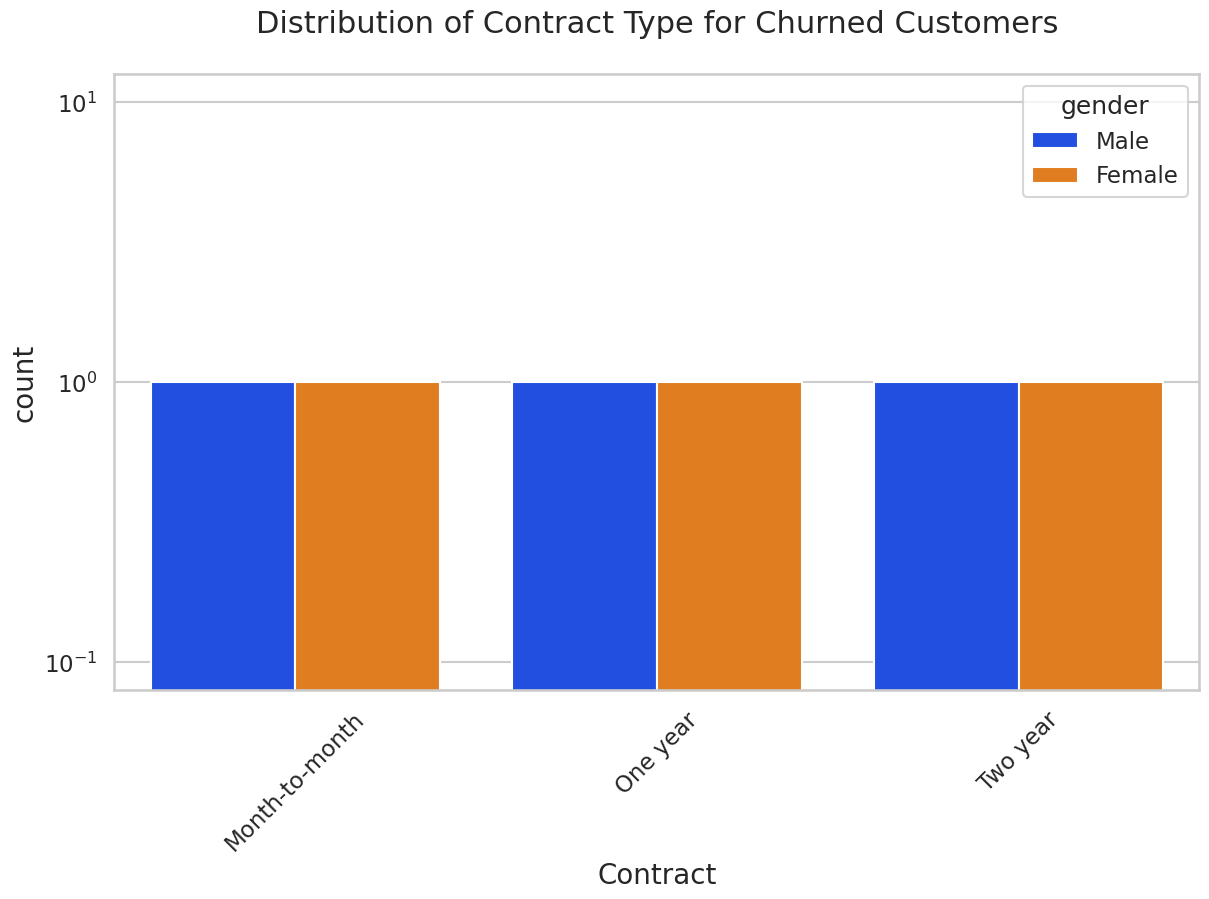

In [57]:
uniplot(new_df1_target1, col='Contract', title='Distribution of Contract Type for Churned Customers', hue='gender')

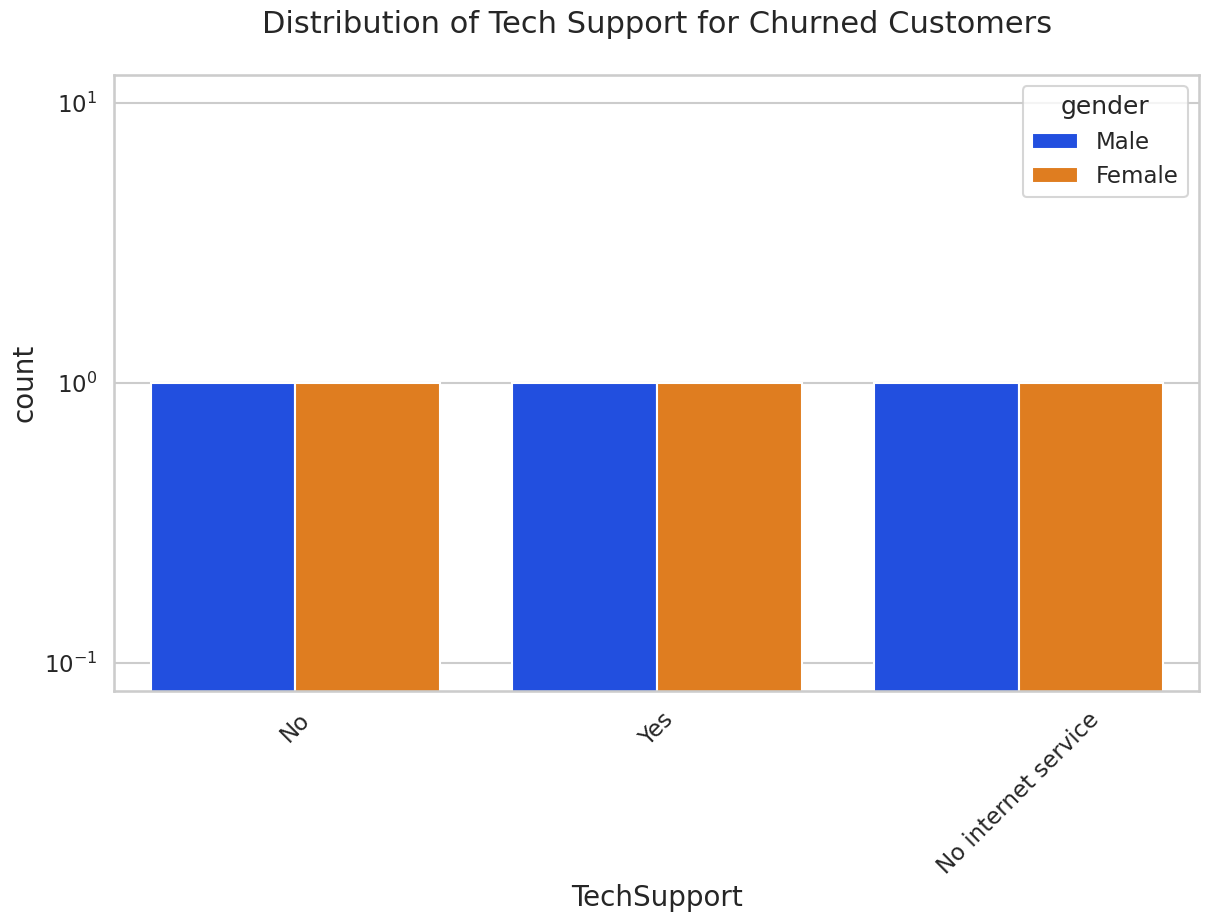

In [58]:
uniplot(new_df1_target1, col='TechSupport', title='Distribution of Tech Support for Churned Customers', hue='gender')

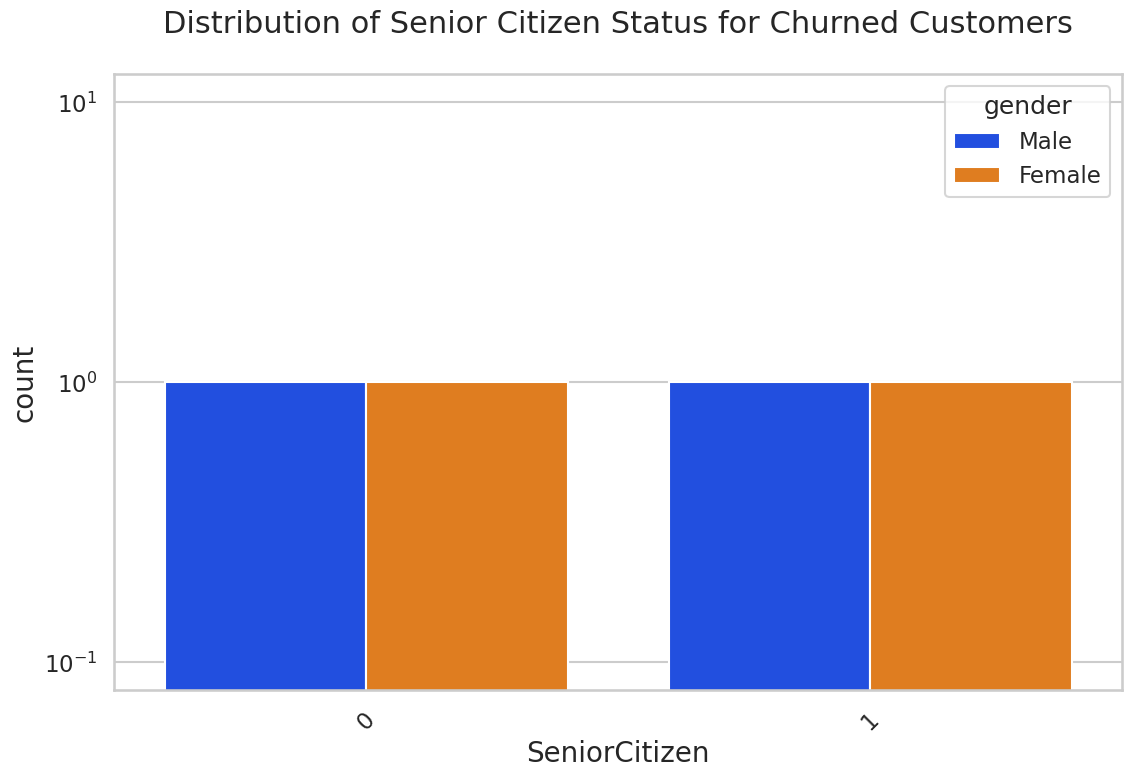

In [59]:
uniplot(new_df1_target1, col='SeniorCitizen', title='Distribution of Senior Citizen Status for Churned Customers', hue='gender')

## Key Findings
Based on the exploratory analysis, the most meaningful churn patterns in this dataset are:

1. **Contract Type** is one of the strongest churn indicators. Customers on **month-to-month contracts** are much more likely to churn than those on annual or two-year plans.
2. **Payment Method** matters. Customers using **electronic check** appear to churn at a higher rate than those using other payment methods.
3. **Service Add-ons** such as **Tech Support** and **Online Security** are associated with stronger retention.
4. **Tenure** is highly informative. Customers in the **early months of their subscription** are more likely to churn.
5. **Billing Patterns** suggest that customers with **higher monthly charges but lower total charges** often churn earlier in the customer lifecycle.

## Business Recommendations
From a business perspective, the EDA suggests a few clear retention opportunities:

- **Target early-life customers** with onboarding and retention campaigns during the first 12 months.
- **Promote longer contract plans** through incentives or loyalty offers.
- **Bundle value-added services** like tech support or online security to improve stickiness.
- **Investigate electronic check users** to understand whether friction in billing or customer profile differences are contributing to churn.
- **Monitor high monthly charge customers** for early dissatisfaction or pricing sensitivity.

## Next Steps
This notebook focuses on exploratory analysis, so the findings are directional rather than causal.

Recommended next steps:
1. Build baseline classification models such as Logistic Regression, Random Forest, and XGBoost.
2. Handle class imbalance during modeling using appropriate evaluation metrics such as ROC-AUC, PR-AUC, and F1-score.
3. Compare feature importance and validate whether EDA observations hold during supervised learning.
4. Convert this dataset into a modeling-ready workflow for preprocessing, training, evaluation, and business interpretation.

## Export for Downstream Modeling
Save the encoded dataset as a CSV file so it can be used in the next stage of the project for model training and evaluation.

In [60]:
new_df_dummies.to_csv('tel_churn.csv', index=False)